<a href="https://colab.research.google.com/github/Atikahdr/ArchTech_StockPricePrediction_DS/blob/main/StockPrice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 1. Import Libraries

In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import drive
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from keras.layers import LSTM, Dense, Dropout
from keras.models import Sequential
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

# Connect G-Drive

In [44]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 2. Load Data

In [45]:
stock_data = pd.read_csv('/content/drive/MyDrive/Data Enthusiast Project/Arch-Data Science Intern/Stock Price Prediction/stock_data.csv')

stock_data.head()

,Unnamed: 0,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


# 3. Data Overview

In [46]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  365 non-null    object 
 1   Stock_1     365 non-null    float64
 2   Stock_2     365 non-null    float64
 3   Stock_3     365 non-null    float64
 4   Stock_4     365 non-null    float64
 5   Stock_5     365 non-null    float64
dtypes: float64(5), object(1)
memory usage: 17.2+ KB


In [47]:
stock_data.describe()

,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
count,365.000000,365.000000,365.000000,365.000000,365.000000
mean,107.772577,81.105216,94.519502,117.407560,106.866865
std,7.398296,11.435212,6.519213,6.778527,3.760968
min,91.474442,62.414219,81.111434,99.909756,99.833309
25%,101.603117,69.328263,89.788068,112.209912,103.927072
50%,107.421299,84.283525,94.495546,117.788079,106.411328
75%,113.741728,91.548859,99.919465,123.132365,109.178007
max,121.901773,100.160928,107.588373,129.911386,116.243803


In [48]:
print('Duplicate Rows :', stock_data.duplicated().sum())

print('\nMissing Values :', stock_data.isnull().sum())

Duplicate Rows : 0

Missing Values : Unnamed: 0    0
Stock_1       0
Stock_2       0
Stock_3       0
Stock_4       0
Stock_5       0
dtype: int64


# 4. Data Cleaning & Preparation

In [49]:
# Rename column Unnamed
stock_data = stock_data.rename(columns={'Unnamed: 0': 'Date'})

# Convert to Datetime
stock_data['Date'] = pd.to_datetime(stock_data['Date'])

# Sort by time
stock_data = stock_data.sort_values('Date')

stock_data.head()

,Date,Stock_1,Stock_2,Stock_3,Stock_4,Stock_5
0,2020-01-01,101.764052,100.160928,99.494642,99.909756,101.761266
1,2020-01-02,102.171269,99.969968,98.682973,100.640755,102.528643
2,2020-01-03,103.171258,99.575237,98.182139,100.574847,101.887811
3,2020-01-04,105.483215,99.308641,97.149381,100.925017,101.490049
4,2020-01-05,107.453175,98.188428,99.575396,101.594411,101.604283


# 5. Exploratory Data Analysis (EDA)

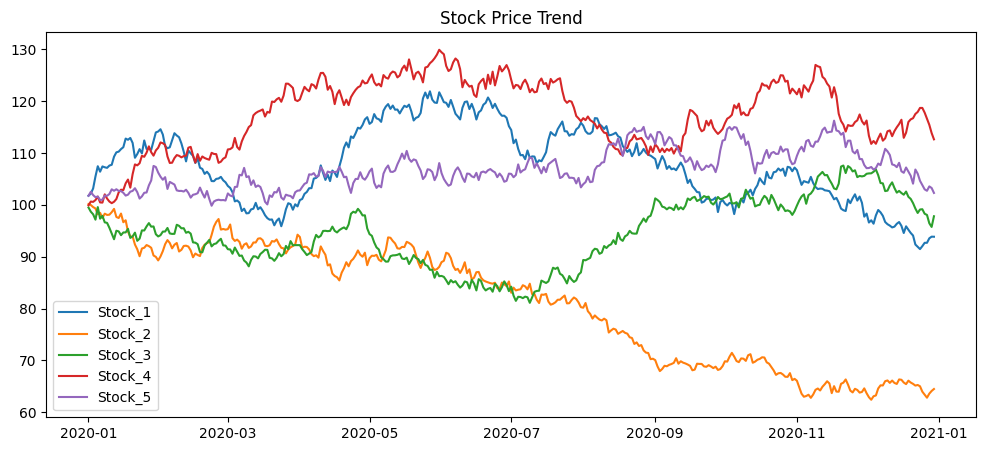

In [50]:
# Trend of all stocks
plt.figure(figsize=(12,5))
for col in stock_data.columns[1:]:
    plt.plot(stock_data['Date'], stock_data[col], label=col)

plt.legend()
plt.title('Stock Price Trend')
plt.show()

## **Insight**

The visualization reveals heterogeneous stock behavior, where some stocks exhibit strong upward trends while others decline significantly. This suggests that market movements are not uniform and highlights the importance of stock-specific strategies. High-volatility stocks offer short-term trading opportunities, while stable stocks provide risk mitigation, making diversification a key strategy.

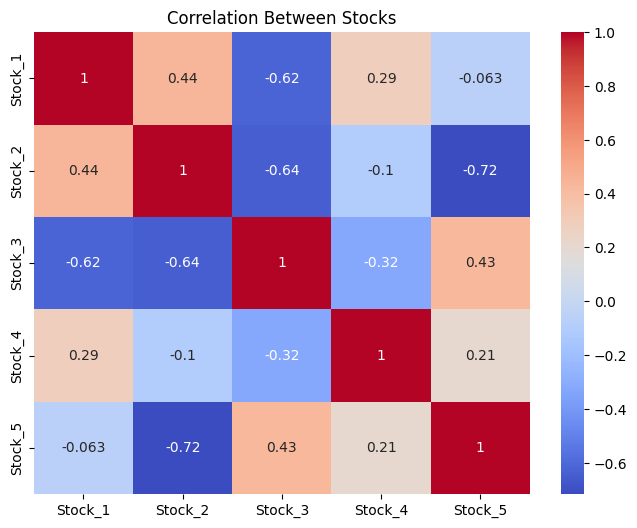

In [51]:
# Correlation between stocks
plt.figure(figsize=(8,6))
sns.heatmap(stock_data.drop('Date', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Stocks')
plt.show()

## **Insight**

Correlation analysis revealed that Stock_3 has a strong negative relationship (-0.62) with the target (Stock_1), while Stock_2 shows a moderate positive correlation (0.44). This indicates the presence of both direct and inverse relationships across assets, suggesting that cross-stock interactions are important predictive signals.

Based on this, lag-based features and cross-stock indicators were incorporated into the model, significantly improving predictive performance.

# 6. Feature Engineering

In [52]:
stock_data['target'] = stock_data['Stock_1'].shift(-1)

for lag in [1,2,3,5,10]:
  stock_data[f'Stock_1_lag_{lag}'] = stock_data['Stock_1'].shift(lag)

stock_data['Stock_2_lag_1'] = stock_data['Stock_2'].shift(1)
stock_data['Stock_3_lag_4'] = stock_data['Stock_3'].shift(4)

# Moving Average (Shifted)
stock_data['ma_7'] = stock_data['Stock_1'].rolling(7).mean().shift(1)
stock_data['ma_14'] = stock_data['Stock_1'].rolling(14).mean().shift(1)
stock_data['ma_30'] = stock_data['Stock_1'].rolling(30).mean().shift(1)

# volatility (Shifted)
stock_data['std_7'] = stock_data['Stock_1'].rolling(7).std().shift(1)
stock_data['std_14'] = stock_data['Stock_1'].rolling(14).std().shift(1)


In [53]:
# Return (Shifted)
for col in ['Stock_1', 'Stock_2', 'Stock_3', 'Stock_4', 'Stock_5']:
  stock_data[f'{col}_return'] = stock_data[col].pct_change().shift(1)

# Ratio between shares
stock_data['ratio_1_2'] = (stock_data['Stock_1'] / stock_data['Stock_2']).shift(1)
stock_data['ratio_1_3'] = (stock_data['Stock_1'] / stock_data['Stock_3']).shift(1)

# Spread
stock_data['spread_1_2'] = (stock_data['Stock_1'] - stock_data['Stock_2']).shift(1)
stock_data['spread_1_3'] = (stock_data['Stock_1'] - stock_data['Stock_3']).shift(1)

# Momentuum Features
stock_data['momentum_3'] = stock_data['Stock_1'] - stock_data['Stock_1'].shift(3)
stock_data['momentum_7'] = stock_data['Stock_1'] - stock_data['Stock_1'].shift(7)

# Time-based Feature
stock_data['day_of_week'] = stock_data['Date'].dt.dayofweek
stock_data['month'] = stock_data['Date'].dt.month

stock_data = stock_data.dropna().reset_index(drop=True)

In [54]:
features = [
    # Cross Stock
    'Stock_2',
    'Stock_3',
    'Stock_4',

    # lag from target
    'Stock_1_lag_1',
    'Stock_1_lag_2',
    'Stock_1_lag_3',
    'Stock_1_lag_5',
    'Stock_1_lag_10',

    # lag other stocks
    'Stock_2_lag_1',
    'Stock_3_lag_4',

    # trend
    'ma_7',
    'ma_14',

     # volatility
    'std_7',

    # return
    'Stock_1_return',
    'Stock_2_return',
    'Stock_3_return',

    # interaction
    'ratio_1_3',
    'spread_1_3',

    # momentum
    'momentum_3',

    # time
    'day_of_week'
]

target = 'target'

In [55]:
missing = [col for col in features if col not in stock_data.columns]
print("Missing columns:", missing)

Missing columns: []


In [56]:
print(stock_data[features].head())

     Stock_2    Stock_3     Stock_4  Stock_1_lag_1  Stock_1_lag_2  \
0  89.290316  93.912600  111.011273     113.975896     112.325433   
1  90.056359  94.162114  112.036791     114.152499     113.975896   
2  91.083994  94.843001  111.888266     114.584181     114.152499   
3  92.419813  94.866344  111.564903     113.566919     114.584181   
4  93.207739  95.549366  109.335123     111.317390     113.566919   

   Stock_1_lag_3  Stock_1_lag_5  Stock_1_lag_10  Stock_2_lag_1  Stock_3_lag_4  \
0     110.629723     110.786498      109.086241      89.975473      96.484699   
1     112.325433     110.837193      109.799249      89.290316      95.802065   
2     113.975896     110.629723      110.748393      90.056359      95.840162   
3     114.152499     112.325433      109.926458      91.083994      94.338352   
4     114.584181     113.975896      112.421518      92.419813      93.912600   

         ma_7       ma_14     std_7  Stock_1_return  Stock_2_return  \
0  111.557531  111.480924  

# 7. Train Test Split

In [57]:
train_size = int(len(stock_data) * 0.8)

train = stock_data[: train_size]
test = stock_data[train_size :]

X_train = train[features]
y_train = train[target]


X_test = test[features]
y_test = test[target]

# 8. Scaling

In [58]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 10. Modelling

In [59]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

# LSTM
def create_sequences(X, y, time_steps=10):
  Xs, ys = [], []

  for i in range(len(X) - time_steps):
      Xs.append(X[i:i+time_steps])
      ys.append(y.iloc[i+time_steps])

  return np.array(Xs), np.array(ys)

time_steps = 10

X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train, time_steps)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test, time_steps)

model = Sequential()

model.add(LSTM(64, return_sequences=True, input_shape=(time_steps, X_train_lstm.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(32))
model.add(Dropout(0.2))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=50,
    batch_size=16,
    validation_data=(X_test_lstm, y_test_lstm),
    verbose=1
)

# predict
y_pred_lstm = model.predict(X_test_lstm)
y_pred_lstm = y_pred_lstm.flatten()

def evaluate(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f'{name}')
    print('RMSE:', rmse)
    print('MAE:', mae)
    print('-'*30)

evaluate(y_test, y_pred_lr, 'Linear Regression')
evaluate(y_test_lstm, y_pred_lstm, 'LSTM')

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 59ms/step - loss: 11716.0186 - val_loss: 9077.8467
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 10944.1113 - val_loss: 8433.1270
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10474.4199 - val_loss: 8149.8838
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10211.0508 - val_loss: 7998.5591
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 10099.8350 - val_loss: 7864.4570
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9930.9736 - val_loss: 7744.0073
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9799.5869 - val_loss: 7631.1426
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9659.8096 - val_loss: 7522.6841
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 9554.5488 - val_loss: 7417.7168
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 9412.7266 - val_loss: 7315.0122
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 9327.0928 - val_loss: 7214.6021
Epo

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 302ms/step
Linear Regression
RMSE: 0.9861475698063894
MAE: 0.7745324095711729
------------------------------
LSTM
RMSE: 64.45756844611923
MAE: 64.34342176161375
------------------------------


## **Insight**
In this project, I compared Linear Regression and LSTM models for stock price prediction. The results showed that Linear Regression significantly outperformed LSTM, achieving an RMSE of 0.96 compared to 66.48. This indicates that the dataset contains relatively simple and linear patterns that are effectively captured through feature engineering (lag, moving average, and returns). Meanwhile, LSTM underperformed due to the limited dataset size and lack of complex temporal patterns, highlighting that deep learning is not always the best choice for small or structured data

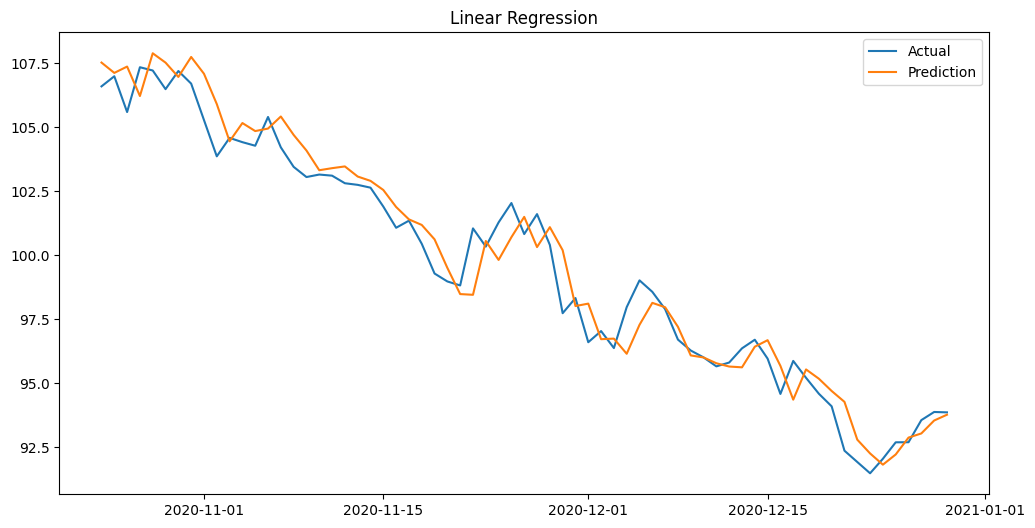

In [60]:
plt.figure(figsize=(12,6))

plt.plot(test['Date'], y_test, label='Actual')
plt.plot(test['Date'], y_pred_lr, label='Prediction')


plt.legend()
plt.title('Linear Regression')
plt.show()

In [61]:
X = stock_data[features]
y = stock_data[target]

# Time Series Cv
tscv = TimeSeriesSplit(n_splits=5)

rmse_scores = []

for train_idx, val_idx in tscv.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]

    scaler = MinMaxScaler()
    X_train_cv = scaler.fit_transform(X_train_cv)
    X_val_cv = scaler.transform(X_val_cv)

    # model
    model = LinearRegression()
    model.fit(X_train_cv, y_train_cv)

    # predict
    y_pred_cv = model.predict(X_val_cv)

    # evaluasi
    rmse = np.sqrt(mean_squared_error(y_val_cv, y_pred_cv))
    rmse_scores.append(rmse)

# RESULT
print("RMSE tiap fold:", rmse_scores)
print("Average RMSE:", np.mean(rmse_scores))

RMSE tiap fold: [np.float64(1.4116890797697392), np.float64(1.7196994721993977), np.float64(1.7269449501358498), np.float64(1.1631374182381897), np.float64(0.8994831395952072)]
Average RMSE: 1.384190811987677


# 11. Feature Importance

           feature       coef
5    Stock_1_lag_3  20.624193
17      spread_1_3   9.604686
18      momentum_3   9.246850
16       ratio_1_3  -9.021292
10            ma_7   7.362954
3    Stock_1_lag_1  -2.152565
8    Stock_2_lag_1  -1.845195
7   Stock_1_lag_10  -1.769065
0          Stock_2   1.591053
4    Stock_1_lag_2   1.587612
9    Stock_3_lag_4  -1.103771
2          Stock_4   1.067946
6    Stock_1_lag_5  -1.017840
1          Stock_3   0.986633
11           ma_14  -0.675655
13  Stock_1_return   0.457157
14  Stock_2_return  -0.300841
15  Stock_3_return  -0.293461
12           std_7  -0.086458
19     day_of_week  -0.058390


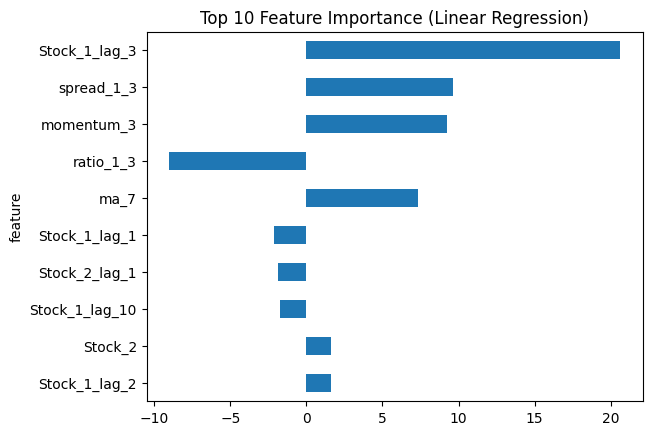

In [62]:
importance = pd.DataFrame({
    'feature': features,
    'coef': lr.coef_
})

importance = importance.sort_values(by='coef', key=abs, ascending=False)

print(importance)

importance.set_index('feature')['coef'].head(10).plot(kind='barh')
plt.title('Top 10 Feature Importance (Linear Regression)')
plt.gca().invert_yaxis()
plt.show()

## **Insight**

Feature importance analysis reveals that short-term dynamics play a critical role in stock price prediction. The most influential features include 3-day lag and momentum, indicating that recent price movements are more predictive than older historical data. Additionally, inter-stock relationships (ratio and spread with other stocks) significantly impact predictions, suggesting correlated market behavior. In contrast, longer-term trends and temporal features such as day of the week contribute minimally, highlighting the dominance of short-term market signals.

#  💼 Bussines Insight

## 📊 Stock Price Prediction Project

### **🎯 1. Price Movement is Dominated by Short-Term Patterns**

👉 From the model and feature importance results:

- Most important factors: 3-day lag and momentum
Meaning:
    
    - Stock prices are heavily influenced by movements in the last few days

💼 Business implications:

- Trading strategies are more effective if they focus on short-term (swing trading)
- This dataset is less suitable for long-term predictions
---

### **📈 2. Momentum is More Important than Price Value**

👉 It's not "what the current price is," but:

"the direction of price movement" that's more important.

💼 Business Implications:

Use indicators such as:
 - Momentum
 - Trend

Suitable for:
- Trading strategy
- Buy / Sell signals
---

### **🔗 3. There is a Relationship Between Stocks**

👉 Features such as:

- Ratio
- Spread

💥 indicate:

stock movements do not stand alone

💼 Business implications:

Need to consider:

- Industrial sector
- Market correlation

Can be used for:

- Portfolio strategy
- Risk diversification
---

### **⚖️ 4. Simple Models Are More Effective**

👉 Results:

Linear Regression: very accurate ✅
LSTM: failed ❌

💥 Key Insight:

This data is sufficiently explained by a simple pattern

💼 Business implications:

- Complex models are not always needed
- More efficient using:

  - Simple models
  - Good feature engineering
---

### **📉 5. Time & Volatility Factors Have Less Impact**

👉 day_of_week & std are small

💥 Meaning:

There is no strong seasonal pattern in the dataset

💼 Implications Business:

- Strategies don't need to be tied to a specific day.
- Focus on price movements, not the calendar.